In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 267
Columns: 9


In [5]:
df.columns

Index(['Region', 'Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1   Date                                      267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [7]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [9]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [10]:
df['Region'] = df['Region'].str.strip()
df['Frequency'] = df['Frequency'].str.strip()

In [11]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage


Region                                     0.0
Date                                       0.0
Frequency                                  0.0
Estimated Unemployment Rate (%)            0.0
Estimated Employed                         0.0
Estimated Labour Participation Rate (%)    0.0
Region.1                                   0.0
longitude                                  0.0
latitude                                   0.0
dtype: float64

In [13]:
numeric_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [14]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

In [15]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [16]:
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                           object
longitude                                         float64
latitude                                          float64
dtype: object

In [17]:
print("Starting date:", df['Date'].min())
print("Ending date:", df['Date'].max())

Starting date: 2020-01-31 00:00:00
Ending date: 2020-10-31 00:00:00


In [18]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal'], dtype=object)

In [19]:
region_avg = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

region_avg

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

Observation

The regional averages show that unemployment rates differ substantially across regions. Some regions consistently experience higher average unemployment than others, indicating differences in labour-market conditions during the study period.

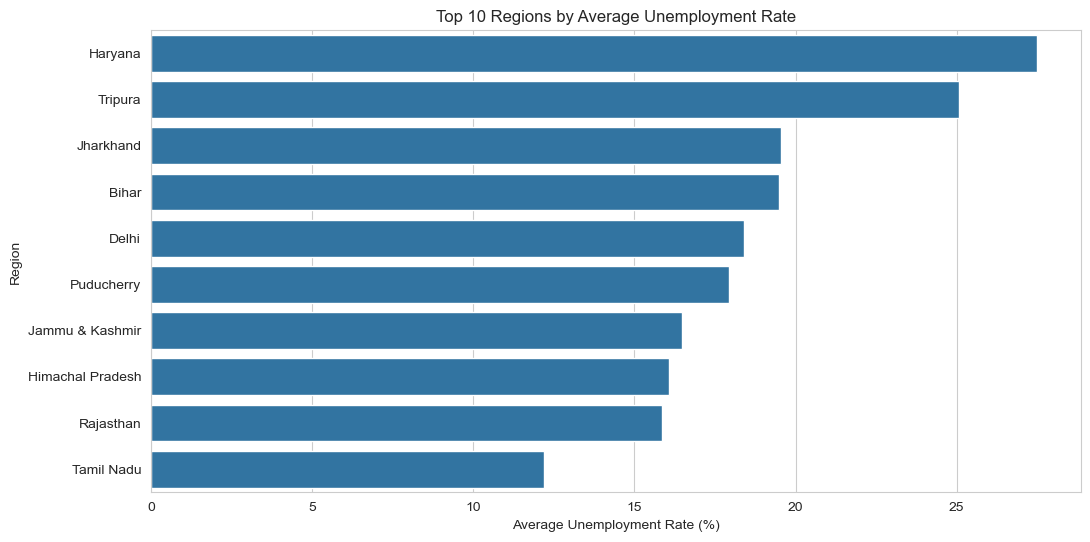

In [20]:
top_10_regions = region_avg.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.show()

Observation

The bar chart identifies the 10 regions with the highest average unemployment rate during the available period. These averages summarize the overall unemployment situation rather than a single month.

In [21]:
df['Month'] = df['Date'].dt.month

In [22]:
monthly_avg = (
    df.groupby('Month')['Estimated Unemployment Rate (%)']
    .mean()
)

monthly_avg

Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64

In [23]:
monthly_avg.index = pd.to_datetime(
    monthly_avg.index,
    format='%m'
).month_name()

monthly_avg

Month
January       9.196538
February      9.266154
March        10.782593
April        22.236154
May          23.244444
June         10.911111
July          9.834444
August       10.313333
September     8.705926
October       8.026296
Name: Estimated Unemployment Rate (%), dtype: float64

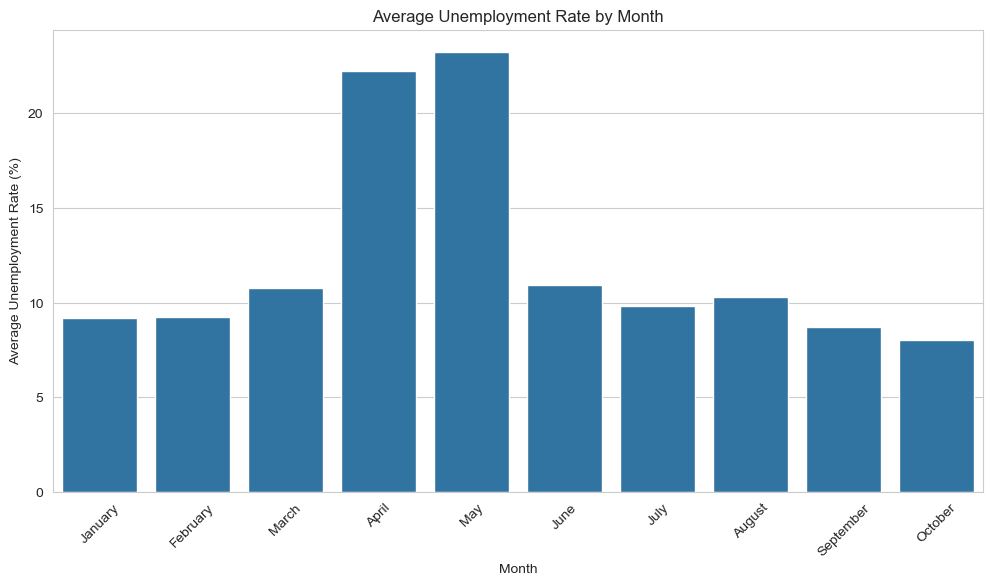

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_avg.index,
    y=monthly_avg.values
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.show()

Observation

The monthly analysis highlights seasonal variation in unemployment. Certain months show higher average unemployment rates than others, which may reflect changes in labour demand and employment conditions.

In [25]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal'], dtype=object)

In [26]:
selected_regions = [
    'Maharashtra',
    'West Bengal',
    'Tamil Nadu'
]

In [27]:
selected_df = df[df['Region'].isin(selected_regions)]

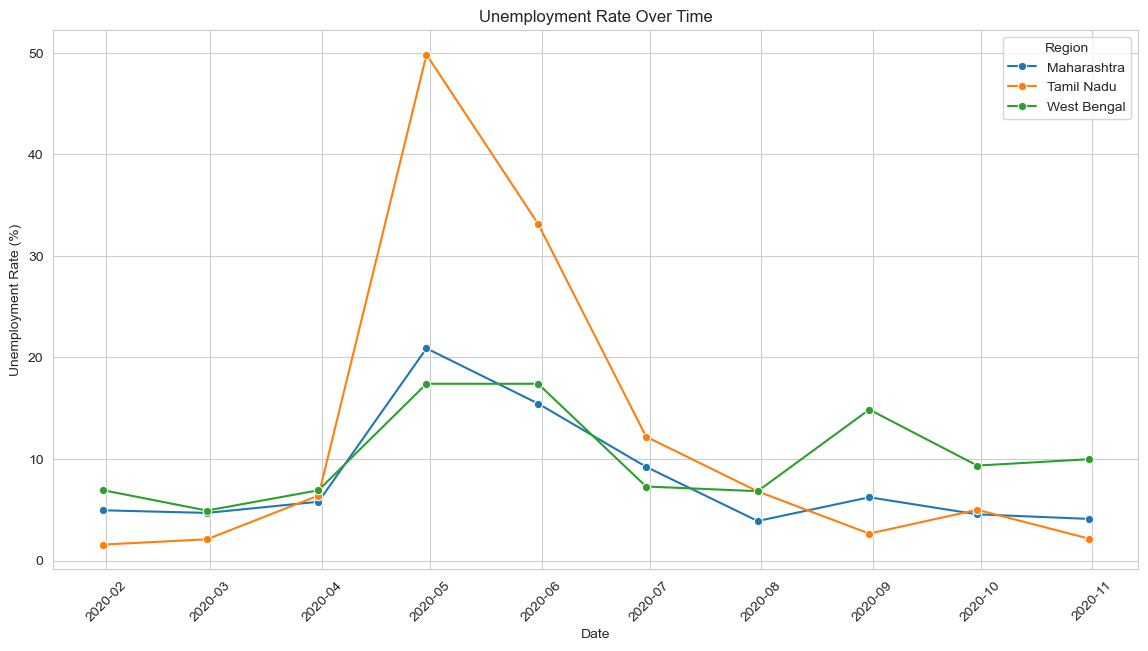

In [28]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=selected_df,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region',
    marker='o'
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.legend(title="Region")

plt.show()

Observation

The time-series chart shows how unemployment changed over time across the selected regions. The lines can be compared to identify periods of increases or decreases and to observe whether the COVID-19 period coincided with unusually high unemployment.

In [29]:
covid_date = pd.Timestamp('2020-03-01')

In [30]:
df['COVID_Period'] = np.where(
    df['Date'] < covid_date,
    'Pre-COVID',
    'COVID/Post-COVID'
)

In [31]:
df[['Date', 'COVID_Period']].head()

,Date,COVID_Period
0,2020-01-31,Pre-COVID
1,2020-02-29,Pre-COVID
2,2020-03-31,COVID/Post-COVID
3,2020-04-30,COVID/Post-COVID
4,2020-05-31,COVID/Post-COVID


In [32]:
period_comparison = df.groupby('COVID_Period')[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Labour Participation Rate (%)',
        'Estimated Employed'
    ]
].mean()

period_comparison

,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%),Estimated Employed
COVID_Period,,,
COVID/Post-COVID,12.963860,41.023209,1.357498e+07
Pre-COVID,9.231346,44.403654,1.556273e+07


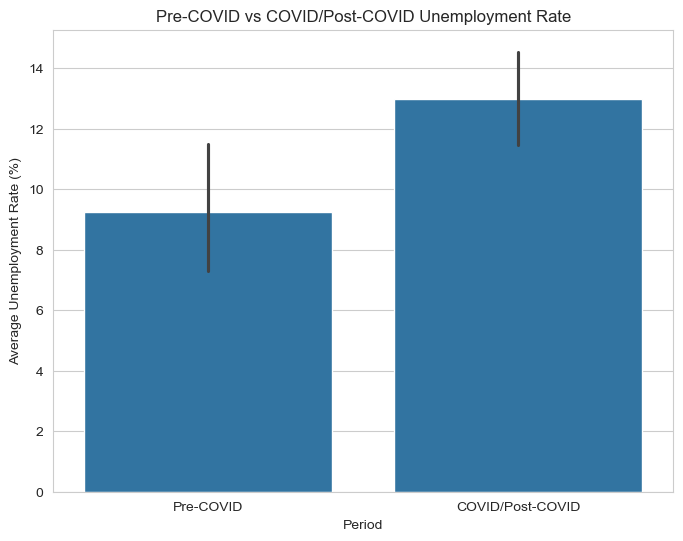

In [33]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df,
    x='COVID_Period',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Pre-COVID vs COVID/Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

COVID-19 Impact

The comparison between the pre-COVID and COVID/post-COVID periods helps identify the change in average unemployment associated with the pandemic period. A substantial increase after March 2020 would indicate that unemployment conditions became more difficult during the pandemic period. This comparison shows association with the period and does not by itself establish that COVID-19 was the sole cause.

In [34]:
correlation_data = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

In [35]:
correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.245176,-0.073540
Estimated Employed,-0.245176,1.000000,-0.047948
Estimated Labour Participation Rate (%),-0.073540,-0.047948,1.000000


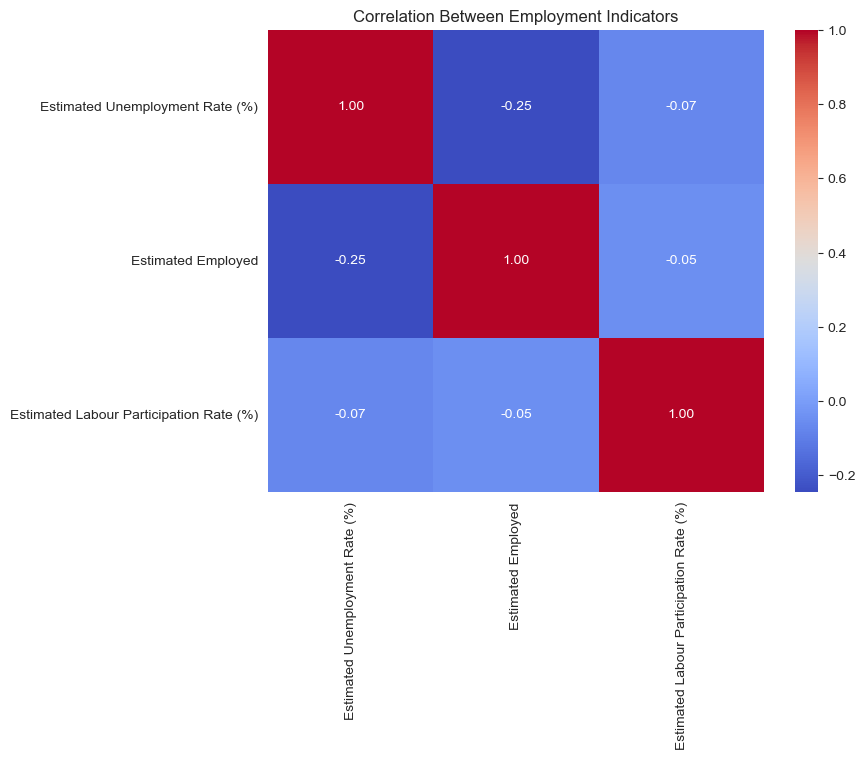

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Employment Indicators")

plt.show()

Observation

The correlation matrix shows the linear relationships between unemployment rate, estimated employment, and labour participation rate. Positive values indicate that two variables tend to increase together, while negative values indicate that one tends to decrease as the other increases. Correlation should not be interpreted as proof of causation.

In [37]:
regional_covid = df.groupby(
    ['Region', 'COVID_Period']
)['Estimated Unemployment Rate (%)'].mean().reset_index()

regional_covid.head()

,Region,COVID_Period,Estimated Unemployment Rate (%)
0,Andhra Pradesh,COVID/Post-COVID,9.41625
1,Andhra Pradesh,Pre-COVID,5.65500
2,Assam,COVID/Post-COVID,4.93625
3,Assam,Pre-COVID,4.53500
4,Bihar,COVID/Post-COVID,21.72625


In [38]:
regional_covid_pivot = regional_covid.pivot(
    index='Region',
    columns='COVID_Period',
    values='Estimated Unemployment Rate (%)'
)

regional_covid_pivot

COVID_Period,COVID/Post-COVID,Pre-COVID
Region,,
Andhra Pradesh,9.416250,5.655
Assam,4.936250,4.535
Bihar,21.726250,10.450
Chhattisgarh,7.520000,9.015
Delhi,18.383750,18.535
Goa,13.746250,5.850
Gujarat,6.480000,5.960
Haryana,28.582500,23.055
Himachal Pradesh,15.872500,16.835


In [39]:
regional_covid_pivot['Change'] = (
    regional_covid_pivot['COVID/Post-COVID']
    - regional_covid_pivot['Pre-COVID']
)

regional_covid_pivot.sort_values(
    'Change',
    ascending=False
).head(10)

COVID_Period,COVID/Post-COVID,Pre-COVID,Change
Region,,,
Puducherry,22.13500,1.170,20.96500
Tamil Nadu,14.77625,1.830,12.94625
Bihar,21.72625,10.450,11.27625
Jharkhand,21.61625,11.230,10.38625
Goa,13.74625,5.850,7.89625
Uttarakhand,12.63500,5.240,7.39500
Karnataka,8.77625,3.235,5.54125
Haryana,28.58250,23.055,5.52750
West Bengal,11.25750,5.930,5.32750


In [40]:
summary = df.groupby('COVID_Period').agg({
    'Estimated Unemployment Rate (%)': 'mean',
    'Estimated Labour Participation Rate (%)': 'mean',
    'Estimated Employed': 'mean'
})

summary

,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%),Estimated Employed
COVID_Period,,,
COVID/Post-COVID,12.963860,41.023209,1.357498e+07
Pre-COVID,9.231346,44.403654,1.556273e+07


In [41]:
summary.round(2)

,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%),Estimated Employed
COVID_Period,,,
COVID/Post-COVID,12.96,41.02,13574977.29
Pre-COVID,9.23,44.40,15562732.90


Conclusion

This exploratory data analysis examined unemployment trends across Indian regions over time. The analysis included regional averages, monthly trends, time-series comparisons, employment indicators, and correlation analysis.

The COVID-19 period was examined by dividing the dataset into pre-COVID and COVID/post-COVID periods. Comparing the average unemployment rates between these periods provides an indication of how unemployment conditions changed around the beginning of the pandemic.

The regional analysis also demonstrates that unemployment conditions varied considerably between regions. The time-series visualization helps identify changes over time, while the correlation heatmap provides insight into relationships among unemployment, employment, and labour participation.

Overall, the analysis demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to investigate regional and temporal unemployment patterns in India.